In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

In [2]:
df = pd.read_csv('tzfor_lightcurve.csv')

In [3]:
df.head()


,HJD,u,v,b,y
0,3029.80535,1.868,1.698,1.047,0.572
1,3029.80957,1.873,1.701,1.054,0.575
2,3029.81330,1.872,1.702,1.054,0.573
3,3029.81739,1.875,1.707,1.053,0.577
4,3029.88190,1.870,1.701,1.050,0.575


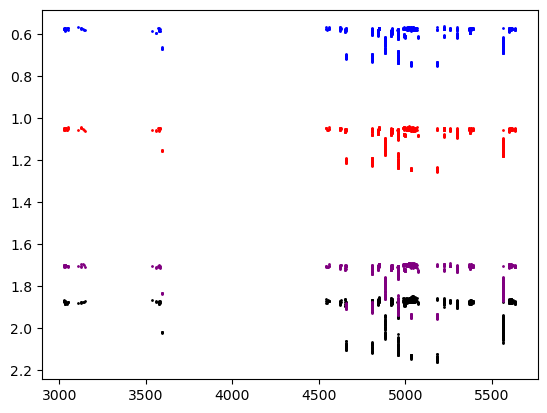

In [4]:
plt.scatter(df['HJD'], df['u'], s=1, color='black');
plt.scatter(df['HJD'], df['v'], s=1, color='purple');
plt.scatter(df['HJD'], df['b'], s=1, color='red');
plt.scatter(df['HJD'], df['y'], s=1, color='blue');
plt.gca().invert_yaxis();

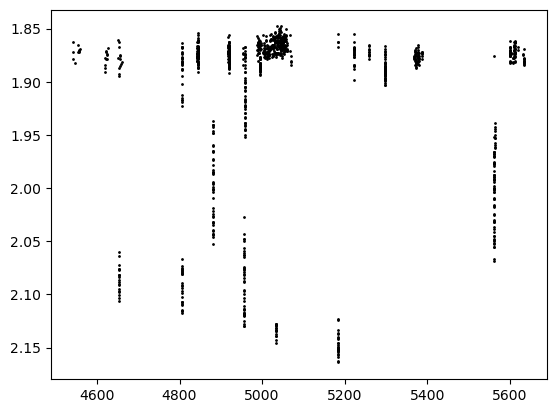

In [5]:
df_c = df[df['HJD']>4500.].reset_index(drop=True)
plt.scatter(df_c['HJD'], df_c['u'], s=1, color='black');
plt.gca().invert_yaxis();

In [6]:
P = 75.666

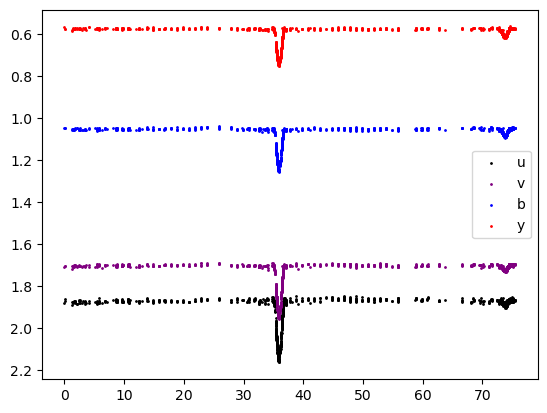

In [16]:
plt.scatter((df_c['HJD']-df_c['HJD'][0])%P, df_c['u'], s=1, color='black', label='u');
plt.scatter((df_c['HJD']-df_c['HJD'][0])%P, df_c['v'], s=1, color='purple', label='v');
plt.scatter((df_c['HJD']-df_c['HJD'][0])%P, df_c['b'], s=1, color='blue', label='b');
plt.scatter((df_c['HJD']-df_c['HJD'][0])%P, df_c['y'], s=1, color='red', label='y');
plt.legend()
plt.gca().invert_yaxis();

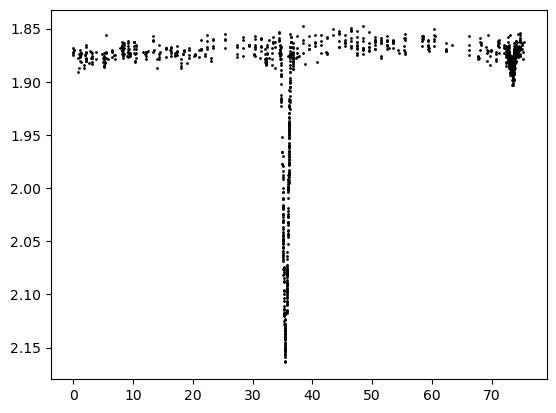

In [8]:
plt.scatter((df['HJD']-df['HJD'][0])%P, df['u'], s=1, color='black')
plt.gca().invert_yaxis();

In [12]:
import astropy.units as u

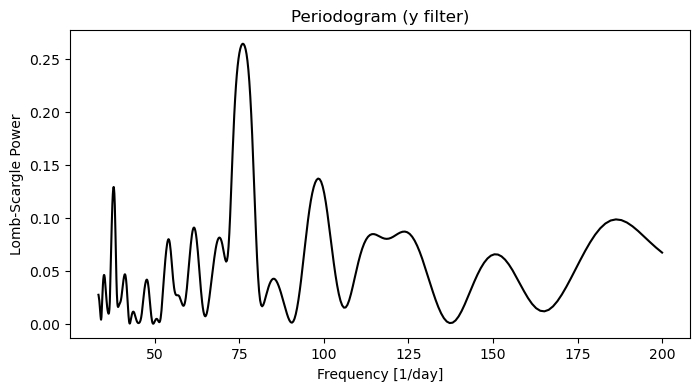

In [13]:
from astropy.timeseries import LombScargle

# Choose a filter for the periodogram analysis, e.g. 'y'
time = df_c['HJD'].values*u.day
flux = df_c['b'].values*u.mag
flux = flux - np.nanmedian(flux)

frequency, power = LombScargle(time, flux).autopower(minimum_frequency=0.005/u.day,
                                                     maximum_frequency=0.03/u.day,
                                                     samples_per_peak=20)

period = 1/frequency
# Plot periodogram
plt.figure(figsize=(8, 4))
plt.plot(period, power, color='black')
plt.xlabel('Frequency [1/day]')
plt.ylabel('Lomb-Scargle Power')
plt.title('Periodogram (y filter)')
plt.show()

In [14]:
1/frequency[np.argmax(power)]

<Quantity 76.04456911 d>

In [15]:
df['HJD'][np.argmax(df['b'])]+2440000

2445183.92451